# 🧠 Perceptron com NumPy + 🌲 Árvore de Decisão no Titanic

Neste notebook você vai:

1. **Implementar um Perceptron do zero** usando apenas `numpy` (sem `scikit-learn` para o modelo).
2. **(Desafio opcional)** Analisar o dataset **Titanic** e treinar um modelo de **Árvore de Decisão** (`DecisionTreeClassifier`).

> 💡 Complete os trechos marcados com `# TODO:` e execute as células na ordem. Mãos à obra!

# Parte 1 — Perceptron do zero com NumPy

## 🧩 O que é o Perceptron?

O Perceptron é um **classificador linear binário**. Para uma entrada $x$ (vetor de características), ele calcula uma combinação linear:

$$z = w \cdot x + b = \sum_{i} w_i\, x_i + b$$

e aplica uma **função degrau** para decidir a classe:

$$\hat{y} = \begin{cases} 1, & \text{se } z \ge 0 \\ 0, & \text{caso contrário} \end{cases}$$

**Regra de aprendizado:** para cada amostra, se houver erro $e = y - \hat{y}$, atualizamos:

$$w \leftarrow w + \eta\, e\, x$$

$$b \leftarrow b + \eta\, e$$

onde $\eta$ é a **taxa de aprendizado** (*learning rate*).

In [32]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)

In [25]:
# Gera um dataset sintético LINEARMENTE SEPARÁVEL com 2 características
n = 100

# Classe 0
X0 = np.random.normal(loc=[2.0, 2.0], scale=1.0, size=(n, 2))

# Classe 1
X1 = np.random.normal(loc=[7.0, 7.0], scale=1.0, size=(n, 2))

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", np.unique(y))

Formato de X: (200, 2)
Formato de y: (200,)
Classes: [0. 1.]


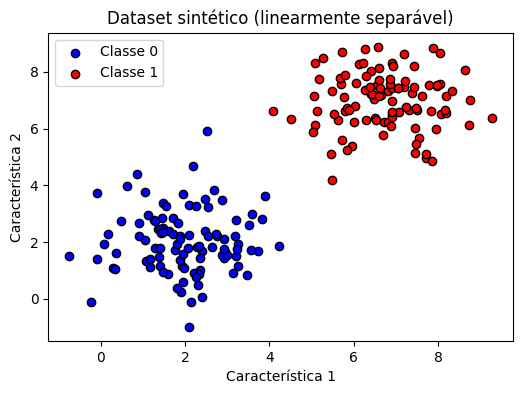

In [26]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', edgecolors='k')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Dataset sintético (linearmente separável)')
plt.legend()
plt.show()

## ✍️ Sua tarefa: implementar o Perceptron

Implemente a classe abaixo **do zero**. Você precisa escrever:

1. **`_step`** — função degrau: retorne `1` se `x >= 0`, senão `0`.
2. **`fit`** — o treinamento:
   - inicialize `self.weights` e `self.bias`;
   - para cada época, percorra todas as amostras;
   - calcule a predição e o erro `erro = y - y_pred`;
   - se houver erro, atualize pesos e bias com a regra do Perceptron.
3. **`predict`** — calcule a saída linear $z = X \cdot w + b$ e aplique a função degrau em cada linha.

In [27]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=50):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def _step(self, x):
      if x >= 0:
        return 1
      else:
        return 0
        # TODO 1: implemente a função degrau (0/1)

    def fit(self, X, y):
        n_samples, n_features = X.shape


        # TODO 2a: inicialize self.weights e self.bias
        self.weights = np.zeros(n_features)
        self.bias = 0.0




        # TODO 2b: laço de treinamento
        #   - para cada época:
        #       - percorra as amostras (xi, yi)
        #       - calcule a predição
        #       - calcule o erro
        #       - se houver erro, atualize pesos e bias
        for i in range((self.n_epochs)):
          for xi, yi in zip(X,y):
            z = np.dot(xi, self.weights) + self.bias
            y_pred = self._step(z)
            erro = yi - y_pred
            if erro != 0:
              self.weights += self.learning_rate * erro * xi
              self.bias += self.learning_rate * erro

        return self

    def predict(self, X):

        # TODO 3: saída linear + função degrau em todas as linhas
        z = np.dot(X, self.weights) + self.bias
        return np.array([self._step(zi) for zi in z])




## 💡 Checklist de funções úteis

- `np.zeros(...)` para inicializar pesos.
- `np.dot(...)` (ou o operador `@`) para o produto escalar / matriz-vetor.
- `zip(X, y)` para percorrer amostra e rótulo juntos.
- Conversão booleana → inteiro: `(z >= 0).astype(int)`.

Pense nos **formatos**: `X` é `(n_amostras, n_features)`, `self.weights` deve ter `n_features` elementos e `self.bias` é um escalar.

In [28]:

model = Perceptron(learning_rate=0.1, n_epochs=100)

model.fit(X, y)

y_pred = model.predict(X)

acuracia = np.mean(y_pred == y)
print("Pesos:", model.weights)
print("Bias:", model.bias)
print(f"Acurácia: {acuracia:.2%}")





Pesos: [0.18763075 0.04293539]
Bias: -0.8999999999999999
Acurácia: 100.00%


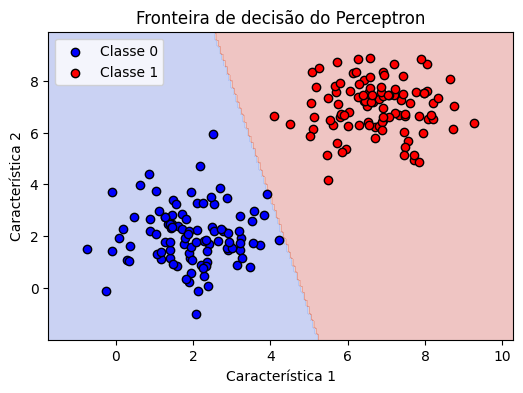

In [29]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', edgecolors='k')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title('Fronteira de decisão do Perceptron')
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y)

## 📝 Questões — Parte 1

1. O que acontece se os dados **não** forem linearmente separáveis? O algoritmo converge?
2. Qual é o papel do *learning rate*? Teste `0.01`, `0.5` e `1.0` e compare.
3. Por que o Perceptron é considerado um classificador **linear**?
4. Teste o que acontece ao remover o `np.random.seed(42)` e gerar os dados novamente.

Pesos iniciais: [0.2814711  1.28248123] | bias inicial: 0.28
learning rate: 0.01 -> acurácia: 98.5 % | pesos: [0.6029833  0.68492698] | bias: 0.07


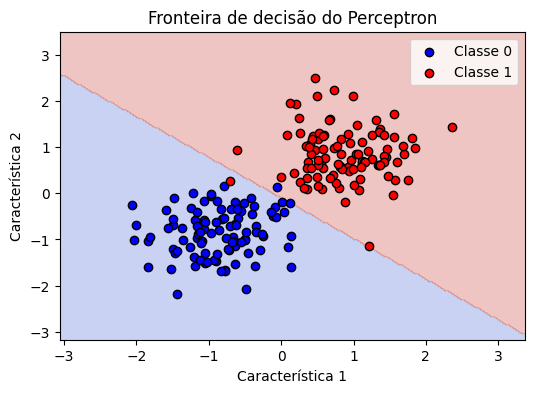

learning rate: 0.5 -> acurácia: 97.5 % | pesos: [1.36235802 0.79059428] | bias: 0.28


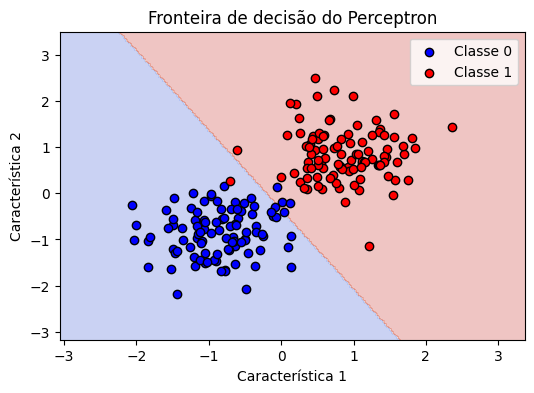

learning rate: 1.0 -> acurácia: 93.5 % | pesos: [2.29750507 1.08512463] | bias: 1.28


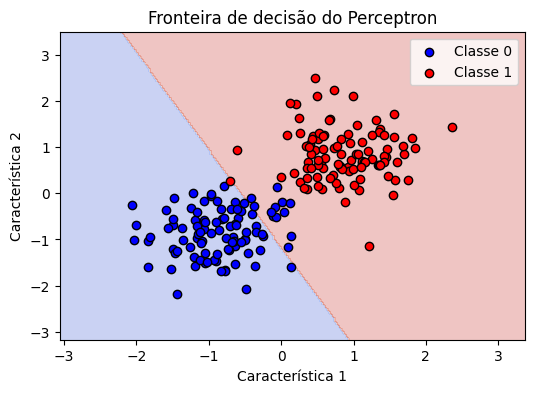

In [31]:
rng = np.random.default_rng(0)
n_ns = 100
X0_ns = rng.normal(loc=[3.0, 3.0], scale=1.2, size=(n_ns, 2))
X1_ns = rng.normal(loc=[7.0, 7.0], scale=1.2, size=(n_ns, 2))
X_ns = np.vstack([X0_ns, X1_ns])
y_ns = np.hstack([np.zeros(n_ns), np.ones(n_ns)])

ordem = rng.permutation(len(y_ns))
X_ns = X_ns[ordem]
y_ns = y_ns[ordem]

X_ns = (X_ns - X_ns.mean(axis=0)) / X_ns.std(axis=0)

peso = rng.normal(0, 1, size=2)
bias = rng.normal(0, 1)
print("Pesos iniciais:", peso, "| bias inicial:", round(bias, 2))

for lr in [0.01, 0.5, 1.0]:
    modelo_ns = Perceptron(learning_rate=lr, n_epochs=100)
    modelo_ns.weights = peso.copy()
    modelo_ns.bias = bias

    for epoca in range(modelo_ns.n_epochs):
        for xi, yi in zip(X_ns, y_ns):
            z = np.dot(xi, modelo_ns.weights) + modelo_ns.bias
            y_pred = modelo_ns._step(z)
            erro = yi - y_pred
            if erro != 0:
                modelo_ns.weights += lr * erro * xi
                modelo_ns.bias += lr * erro

    acc_ns = np.mean(modelo_ns.predict(X_ns) == y_ns)
    print("learning rate:", lr, "-> acurácia:", round(acc_ns * 100, 2), "% | pesos:", modelo_ns.weights, "| bias:", round(modelo_ns.bias, 2))
    plot_decision_boundary(modelo_ns, X_ns, y_ns)
# 1.Não converge,a apenas sempre ira sobrar erro.

# 2.O learning rate define o tamanho dos ajustes nos pesos.

# 3.Porque a fronteira de decisão responsavel pos separar os objetos analisados é uma reta.

# 4. Os dados e os pesos mudam a cada execução.

# Parte 2 (Desafio opcional) — Titanic + Árvore de Decisão 🌲

## 🚢 O dataset Titanic

O objetivo é prever se um passageiro **sobreviveu** (`Survived`) ao naufrágio usando características como classe (`Pclass`), sexo (`Sex`), idade (`Age`), etc.

| Coluna | Descrição |
|---|---|
| `Survived` | 0 = não sobreviveu, 1 = sobreviveu (**alvo**) |
| `Pclass` | Classe da passagem (1, 2, 3) |
| `Sex` | Sexo do passageiro |
| `Age` | Idade |
| `SibSp` | Nº de irmãos/cônjuges a bordo |
| `Parch` | Nº de pais/filhos a bordo |
| `Fare` | Tarifa paga |
| `Embarked` | Porto de embarque (C, Q, S) |

Aqui você vai conduzir a análise do zero: explorar, pré-processar e treinar a **Árvore de Decisão**.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

titanic.head()

In [ ]:
# Exploração inicial
titanic.info()
print()
print("Valores ausentes por coluna:")
print(titanic.isna().sum())

## 🔎 Roteiro da análise

Siga as etapas abaixo (cada uma tem uma célula `TODO`):

1. **Análise exploratória** da taxa de sobrevivência.
2. **Pré-processamento**: remover colunas irrelevantes, tratar valores ausentes e codificar categóricas.
3. **Divisão** treino/teste.
4. **Treinamento** da Árvore de Decisão.
5. **Avaliação** (acurácia, matriz de confusão, relatório).
6. **Interpretação** (importância das features e visualização da árvore).

In [ ]:
# TODO 1: análise exploratória da taxa de sobrevivência
# - sobrevivência geral
# - por sexo (groupby('Sex'))
# - por classe (groupby('Pclass'))
# - por porto de embarque (groupby('Embarked'))

# seu código aqui

## 🧹 Pré-processamento

Lembre-se de:

- **Remover** colunas que não ajudam a prever (`PassengerId`, `Name`, `Ticket`, `Cabin`).
- **Preencher** valores ausentes: mediana para `Age` e `Fare`; moda para `Embarked`.
- **Codificar** `Sex` e `Embarked` em números (ex.: `male` → 0, `female` → 1).

In [ ]:
# TODO 2: pré-processamento
# - remova colunas irrelevantes
# - preencha valores ausentes (mediana / moda)
# - codifique Sex e Embarked em números
# - confirme que não sobraram valores ausentes

# seu código aqui

In [ ]:
# TODO 3: separe features (X) e alvo (y) e divida em treino/teste
# - escolha as colunas de features
# - use train_test_split com test_size=0.2, random_state=42 e stratify=y

# seu código aqui

## 🌲 Treinando a Árvore de Decisão

Crie e treine um `DecisionTreeClassifier`. Experimente diferentes valores de `max_depth` (ex.: `None`, `3`, `5`, `10`) e observe o efeito na acurácia e no *overfitting*.

In [ ]:
# TODO 4: crie e treine o modelo de Árvore de Decisão
# - instancie DecisionTreeClassifier(...)
# - treine com .fit(X_train, y_train)
# - faça predições no teste

# seu código aqui

In [ ]:
# TODO 5: avalie o modelo no conjunto de teste
# - acurácia (accuracy_score)
# - matriz de confusão (confusion_matrix)
# - relatório de classificação (classification_report)
# - (opcional) ConfusionMatrixDisplay.from_predictions

# seu código aqui

In [ ]:
# TODO 6: interprete o modelo
# - extraia model.feature_importances_ e plote (plt.barh)
# - (opcional) visualize a árvore com sklearn.tree.plot_tree

# seu código aqui

## 📝 Questões — Parte 2

1. Quais features foram as mais importantes para a árvore? Isso faz sentido historicamente?
2. O que acontece com a acurácia quando você aumenta muito `max_depth`? E o risco de *overfitting*?
3. Como você melhoraria o modelo? (ex.: criar novas features, tratar `Age` de outra forma, usar *random forest*, etc.)
4. Compare a Árvore de Decisão com o Perceptron da Parte 1: quais as diferenças entre um modelo linear e um modelo baseado em árvore?

## 🎓 Conclusão

- O **Perceptron** é um modelo linear simples, bom para problemas **linearmente separáveis**.
- A **Árvore de Decisão** aprende regras *não lineares* e é **interpretável**, mas pode sofrer *overfitting*.
- O pré-processamento (valores ausentes e codificação de categóricas) é fundamental antes de treinar qualquer modelo.

Bons estudos! 🚀